In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

# Set plot style
sns.set_style("whitegrid")
print("Imports successful")

Imports successful


In [6]:
# Load the cleaned reviews (created in Task 1)
df = pd.read_csv('data/raw/cleaned_reviews.csv')
print(f"Loaded {len(df)} reviews")
df.head()

Loaded 1134 reviews


,review,rating,date,bank,source
0,formative,5,2026-05-14,Commercial Bank of Ethiopia,Google Play
1,best app for financial activities 🙌,5,2026-05-14,Commercial Bank of Ethiopia,Google Play
2,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,Commercial Bank of Ethiopia,Google Play
3,incredible,5,2026-05-14,Commercial Bank of Ethiopia,Google Play
4,best app for financial sector,5,2026-05-14,Commercial Bank of Ethiopia,Google Play


In [7]:
def get_sentiment(text):
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity  # -1 (negative) to +1 (positive)
    if polarity > 0.05:
        label = 'POSITIVE'
    elif polarity < -0.05:
        label = 'NEGATIVE'
    else:
        label = 'NEUTRAL'
    score = abs(polarity)  # confidence as absolute polarity
    return label, score

# Apply to each review
df[['sentiment_label', 'sentiment_score']] = df['review'].apply(lambda x: pd.Series(get_sentiment(x)))
df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score
0,formative,5,2026-05-14,Commercial Bank of Ethiopia,Google Play,NEUTRAL,0.0
1,best app for financial activities 🙌,5,2026-05-14,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.5
2,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,Commercial Bank of Ethiopia,Google Play,NEUTRAL,0.0
3,incredible,5,2026-05-14,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.9
4,best app for financial sector,5,2026-05-14,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.5


Sentiment counts per bank:
sentiment_label              NEGATIVE  NEUTRAL  POSITIVE
bank                                                    
Bank of Abyssinia                  60      157       163
Commercial Bank of Ethiopia        30      137       207
Dashen Bank                        38      138       204


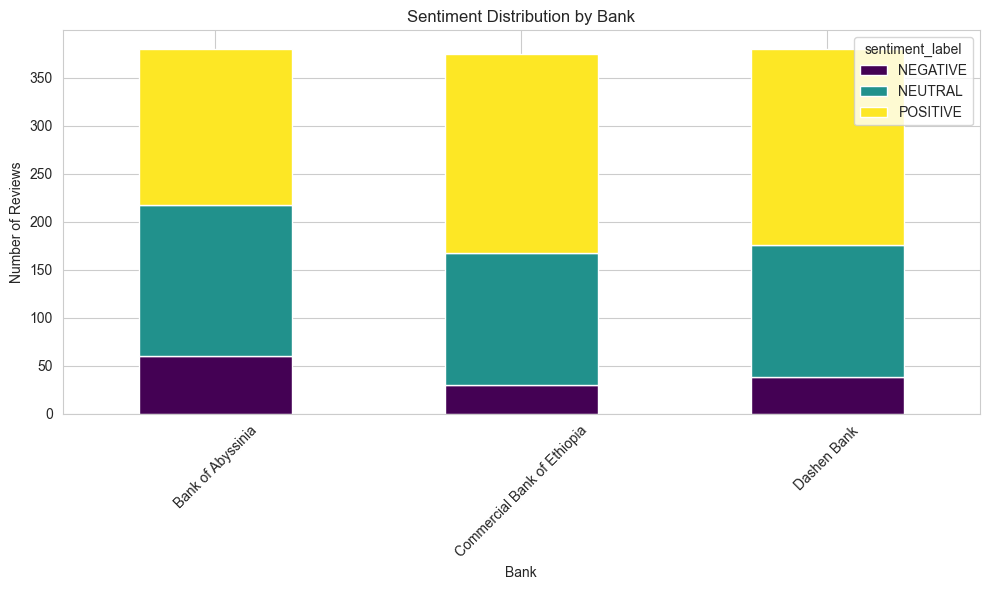

In [8]:
# Count sentiment labels per bank
sentiment_counts = df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
print("Sentiment counts per bank:")
print(sentiment_counts)

# Plot
sentiment_counts.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average sentiment score per star rating:
rating
1    0.240590
2    0.237189
3    0.245138
4    0.262944
5    0.391897
Name: sentiment_score, dtype: float64


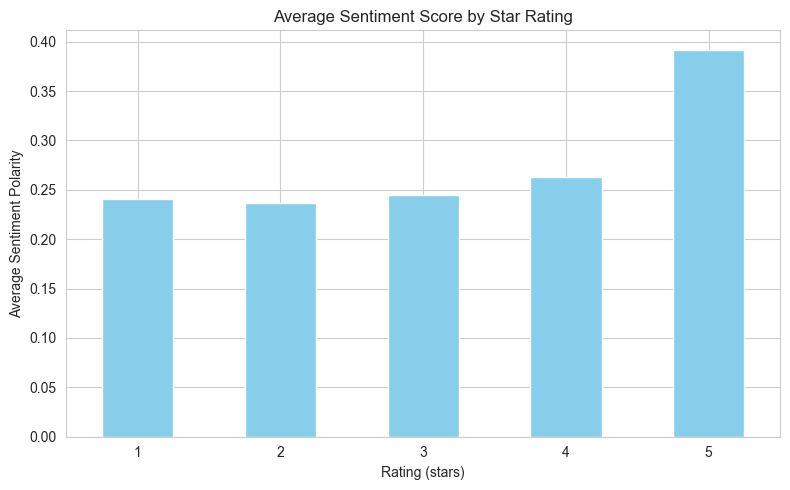

In [9]:
avg_sentiment_by_rating = df.groupby('rating')['sentiment_score'].mean()
print("Average sentiment score per star rating:")
print(avg_sentiment_by_rating)

# Plot
plt.figure(figsize=(8,5))
avg_sentiment_by_rating.plot(kind='bar', color='skyblue')
plt.title('Average Sentiment Score by Star Rating')
plt.xlabel('Rating (stars)')
plt.ylabel('Average Sentiment Polarity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
def get_top_keywords(texts, n=10):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=n)
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    return feature_names

# For each bank, extract top keywords
banks = df['bank'].unique()
keywords_by_bank = {}
for bank in banks:
    texts = df[df['bank'] == bank]['review'].tolist()
    keywords = get_top_keywords(texts, n=10)
    keywords_by_bank[bank] = keywords
    print(f"\nTop keywords for {bank}:\n{list(keywords)}")


Top keywords for Commercial Bank of Ethiopia:
['app', 'application', 'bank', 'best', 'cbe', 'good', 'nice', 'update', 'work', 'working']

Top keywords for Bank of Abyssinia:
['app', 'bank', 'banking', 'best', 'boa', 'good', 'mobile', 'use', 'work', 'working']

Top keywords for Dashen Bank:
['amole', 'app', 'bank', 'banking', 'best', 'dashen', 'good', 'time', 'update', 'use']


In [11]:
# Example theme mapping – replace with actual keywords you observed
themes = {
    'Commercial Bank of Ethiopia': {
        'Performance': ['fast', 'smooth', 'crash', 'slow', 'freeze'],
        'Authentication': ['login', 'otp', 'password', 'fingerprint'],
        'Features': ['transfer', 'balance', 'statement', 'qr']
    },
    'Bank of Abyssinia': {
        'Performance': ['fast', 'smooth', 'crash', 'slow', 'freeze'],
        'Authentication': ['login', 'otp', 'password', 'fingerprint'],
        'Features': ['transfer', 'balance', 'statement', 'qr']
    },
    'Dashen Bank': {
        'Performance': ['fast', 'smooth', 'crash', 'slow', 'freeze'],
        'Authentication': ['login', 'otp', 'password', 'fingerprint'],
        'Features': ['transfer', 'balance', 'statement', 'qr']
    }
}

# Print themes per bank
for bank, theme_dict in themes.items():
    print(f"\n{bank} themes:")
    for theme, words in theme_dict.items():
        print(f"  {theme}: {', '.join(words)}")


Commercial Bank of Ethiopia themes:
  Performance: fast, smooth, crash, slow, freeze
  Authentication: login, otp, password, fingerprint
  Features: transfer, balance, statement, qr

Bank of Abyssinia themes:
  Performance: fast, smooth, crash, slow, freeze
  Authentication: login, otp, password, fingerprint
  Features: transfer, balance, statement, qr

Dashen Bank themes:
  Performance: fast, smooth, crash, slow, freeze
  Authentication: login, otp, password, fingerprint
  Features: transfer, balance, statement, qr


In [12]:
def assign_theme(text, theme_dict):
    text_lower = text.lower()
    for theme, words in theme_dict.items():
        for word in words:
            if word in text_lower:
                return theme
    return 'Other'

# Apply theme assignment (using the theme dictionary for the respective bank)
df['theme'] = None
for bank in df['bank'].unique():
    mask = df['bank'] == bank
    df.loc[mask, 'theme'] = df.loc[mask, 'review'].apply(lambda x: assign_theme(x, themes[bank]))
df[['review', 'sentiment_label', 'theme']].head()

,review,sentiment_label,theme
0,formative,NEUTRAL,Other
1,best app for financial activities 🙌,POSITIVE,Other
2,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,NEUTRAL,Other
3,incredible,POSITIVE,Other
4,best app for financial sector,POSITIVE,Other


In [13]:
df.to_csv('data/raw/reviews_with_sentiment.csv', index=False)
print("Enriched dataset saved to data/raw/reviews_with_sentiment.csv")

Enriched dataset saved to data/raw/reviews_with_sentiment.csv


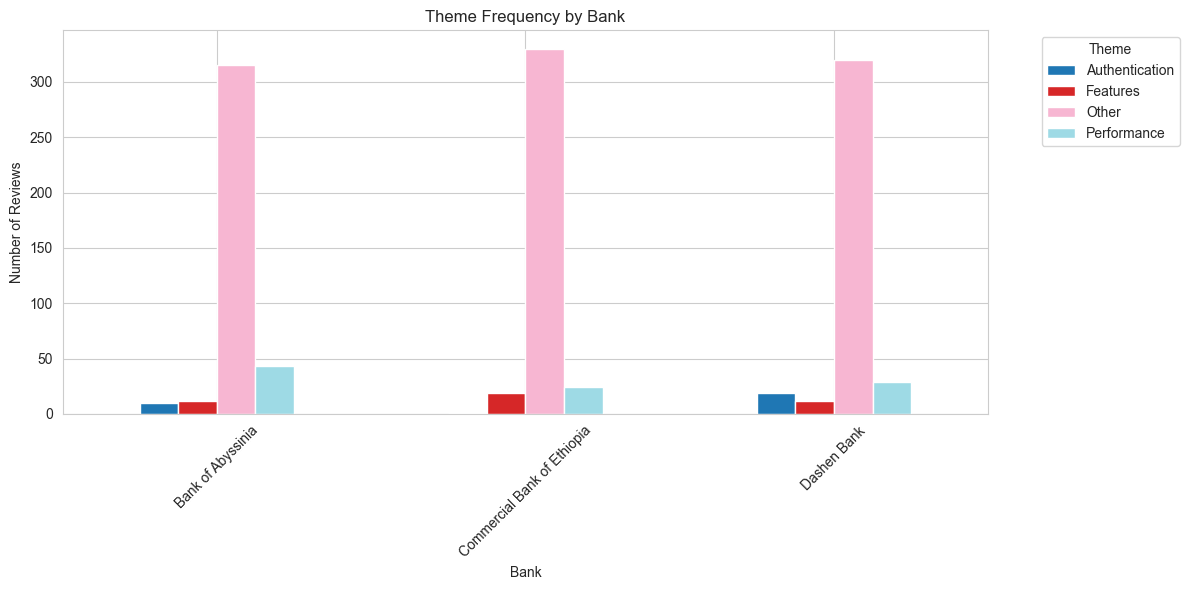

In [14]:
# Count themes per bank
theme_counts = df.groupby(['bank', 'theme']).size().unstack(fill_value=0)
theme_counts.plot(kind='bar', figsize=(12,6), colormap='tab20')
plt.title('Theme Frequency by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()